# 📊 Advertising Dataset — Regression Analysis

## Overview
This notebook analyzes the **Advertising dataset**, which records advertising budgets (TV, Radio, Newspaper) and the resulting Sales figures across 200 markets.

**Goal:** Predict `Sales` from advertising spend using 4 regression models.

---
### Table of Contents
1. Import Libraries
2. Load & Explore Data
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Preprocessing
5. Model Training & Evaluation
6. Model Comparison
7. Feature Importance


---
## 1. Import Libraries

All required libraries for data manipulation, visualization, and machine learning are imported here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

---
## 2. Load & Explore Data

The dataset is loaded from CSV. The index column (`Unnamed: 0`) is dropped as it adds no information. Basic shape, data types, missing values, and statistical summaries are inspected.

In [2]:
df = pd.read_csv(r'C:\Users\ACER\OneDrive\Desktop\Bull\New folder\OIBSIP\Sales Prediction\Dataset\Advertising.csv', index_col=0)
print(f'Shape: {df.shape}')
df.head()

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [4]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Each Feature

Histograms show the distribution of each advertising channel and the target variable `Sales`. This helps identify skewness and potential outliers.

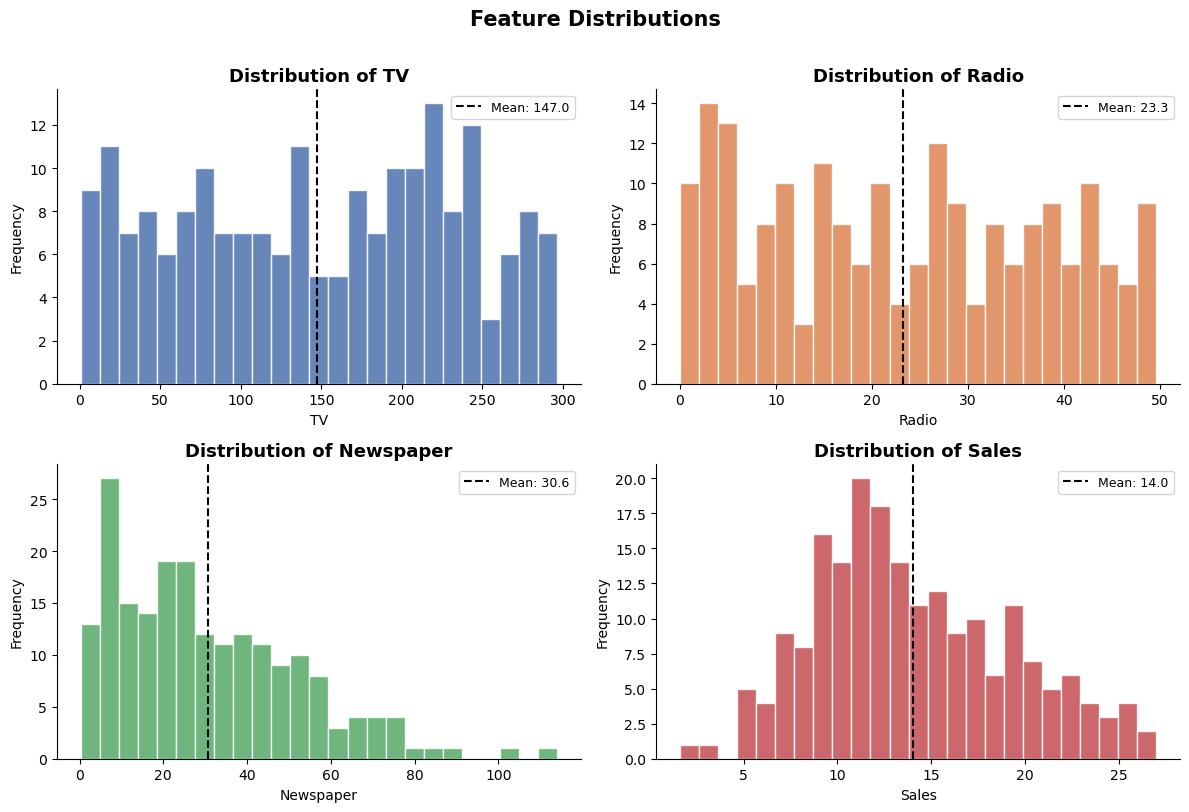

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ['TV', 'Radio', 'Newspaper', 'Sales']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, color in zip(axes.flatten(), cols, colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Correlation Heatmap

A heatmap of Pearson correlations reveals how strongly each advertising channel is linearly associated with Sales and with each other.

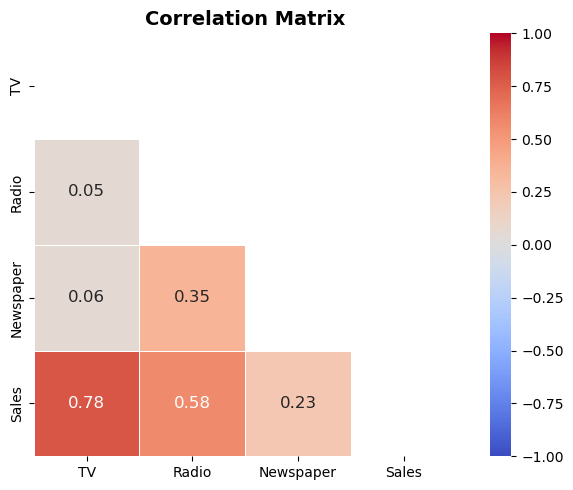

In [6]:
plt.figure(figsize=(7, 5))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True,
            annot_kws={'size': 12})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Scatter Plots — Feature vs Sales

Scatter plots with regression lines show the individual linear relationship between each advertising medium and Sales.

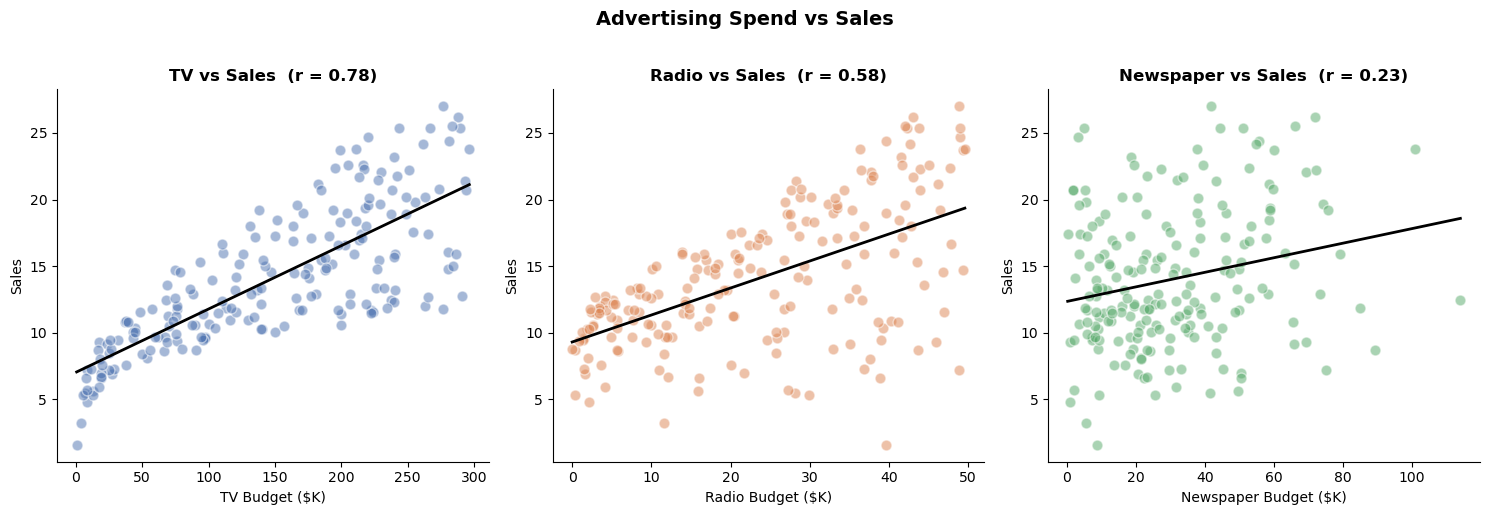

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
features = ['TV', 'Radio', 'Newspaper']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, feat, color in zip(axes, features, colors):
    ax.scatter(df[feat], df['Sales'], alpha=0.5, color=color, edgecolors='white', s=60)
    m, b = np.polyfit(df[feat], df['Sales'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=2)
    corr_val = df[feat].corr(df['Sales'])
    ax.set_title(f'{feat} vs Sales  (r = {corr_val:.2f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{feat} Budget ($K)')
    ax.set_ylabel('Sales')

plt.suptitle('Advertising Spend vs Sales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Boxplots — Spread & Outliers

Boxplots show the spread, median, and potential outliers for each variable.

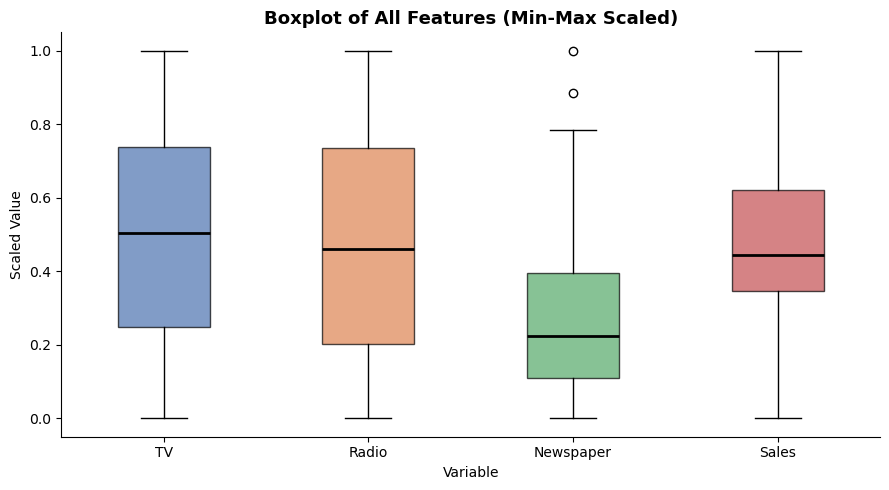

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
df_scaled = (df - df.min()) / (df.max() - df.min())
bp = ax.boxplot([df_scaled[col] for col in df.columns],
                labels=df.columns, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

box_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Boxplot of All Features (Min-Max Scaled)', fontsize=13, fontweight='bold')
ax.set_ylabel('Scaled Value')
ax.set_xlabel('Variable')
plt.tight_layout()
plt.show()

### 3.5 Pairplot

A pairplot gives a comprehensive view of all pairwise relationships and individual distributions in one chart.

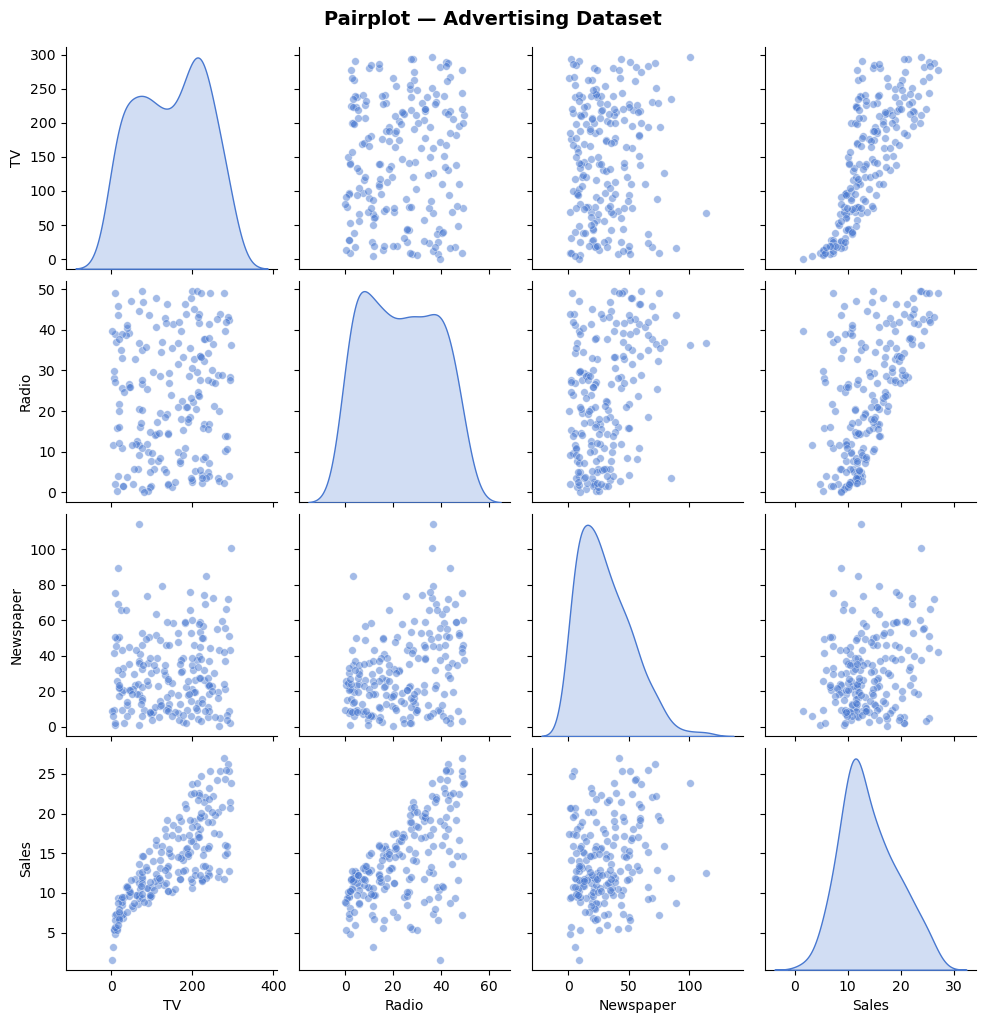

In [9]:
g = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 diag_kws={'fill': True})
g.fig.suptitle('Pairplot — Advertising Dataset', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 4. Feature Engineering & Preprocessing

The feature matrix `X` and target vector `y` are defined. The data is split into **80% training** and **20% test** sets. Features are standardized using `StandardScaler` (important for Ridge Regression).

In [10]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 160 | Test size: 40


---
## 5. Model Training & Evaluation

Four regression models are trained and evaluated:

| # | Model | Why? |
|---|-------|------|
| 1 | **Linear Regression** | Baseline; interpretable coefficients |
| 2 | **Ridge Regression** | Handles multicollinearity with L2 regularization |
| 3 | **Random Forest** | Non-linear ensemble; robust to noise |
| 4 | **Gradient Boosting** | Sequential boosting; typically best accuracy |

Metrics computed: **R²**, **RMSE**, **MAE**.

In [11]:
models = {
    'Linear Regression':     LinearRegression(),
    'Ridge Regression':      Ridge(alpha=1.0),
    'Random Forest':         RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    X_tr = X_train_sc if name in ['Linear Regression', 'Ridge Regression'] else X_train
    X_te = X_test_sc  if name in ['Linear Regression', 'Ridge Regression'] else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    predictions[name] = y_pred

    cv_r2 = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2').mean()

    results[name] = {
        'R2':   round(r2_score(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4),
        'CV R2 (5-fold)': round(cv_r2, 4)
    }

results_df = pd.DataFrame(results).T
results_df

,R2,RMSE,MAE,CV R2 (5-fold)
Linear Regression,0.8994,1.7816,1.4608,0.8595
Ridge Regression,0.8988,1.7872,1.4643,0.8597
Random Forest,0.9818,0.7572,0.6287,0.9701
Gradient Boosting,0.9833,0.7259,0.6084,0.9695


---
## 6. Model Comparison

### 6.1 Metric Bar Charts

Bar charts compare all models across R², RMSE, and MAE simultaneously.

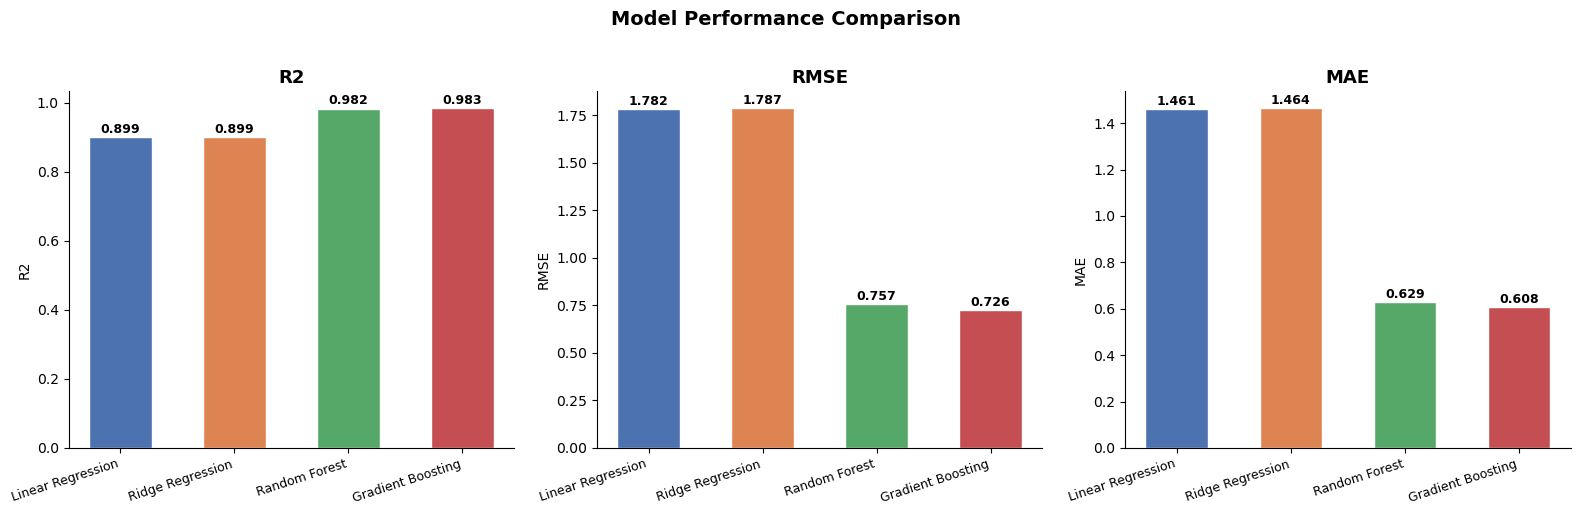

In [12]:
metrics = ['R2', 'RMSE', 'MAE']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].astype(float)
    bars = ax.bar(results_df.index, vals, color=bar_colors, edgecolor='white', width=0.55)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(results_df.index, rotation=18, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Actual vs Predicted Plots

These scatter plots compare each model's predictions against the true Sales values. A perfect model would produce all points on the dashed diagonal line.

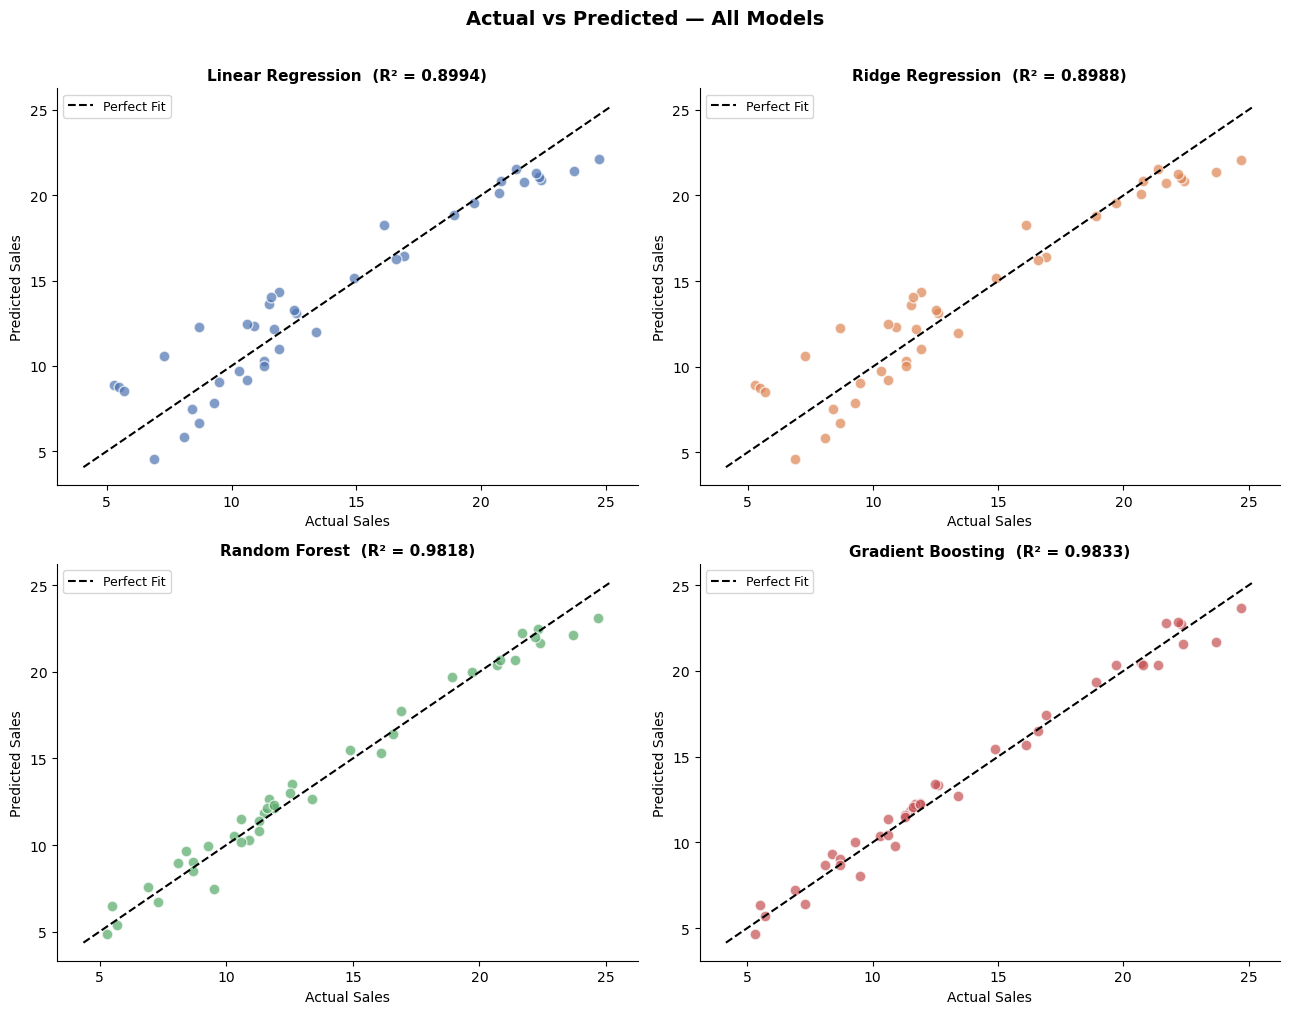

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (name, y_pred), color in zip(axes.flatten(), predictions.items(), bar_colors):
    ax.scatter(y_test, y_pred, alpha=0.7, color=color, edgecolors='white', s=60)
    lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Fit')
    r2 = results[name]['R2']
    ax.set_title(f'{name}  (R² = {r2})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.3 Residual Plots

Residuals (Actual − Predicted) should be randomly scattered around zero. Patterns indicate model mis-specification.

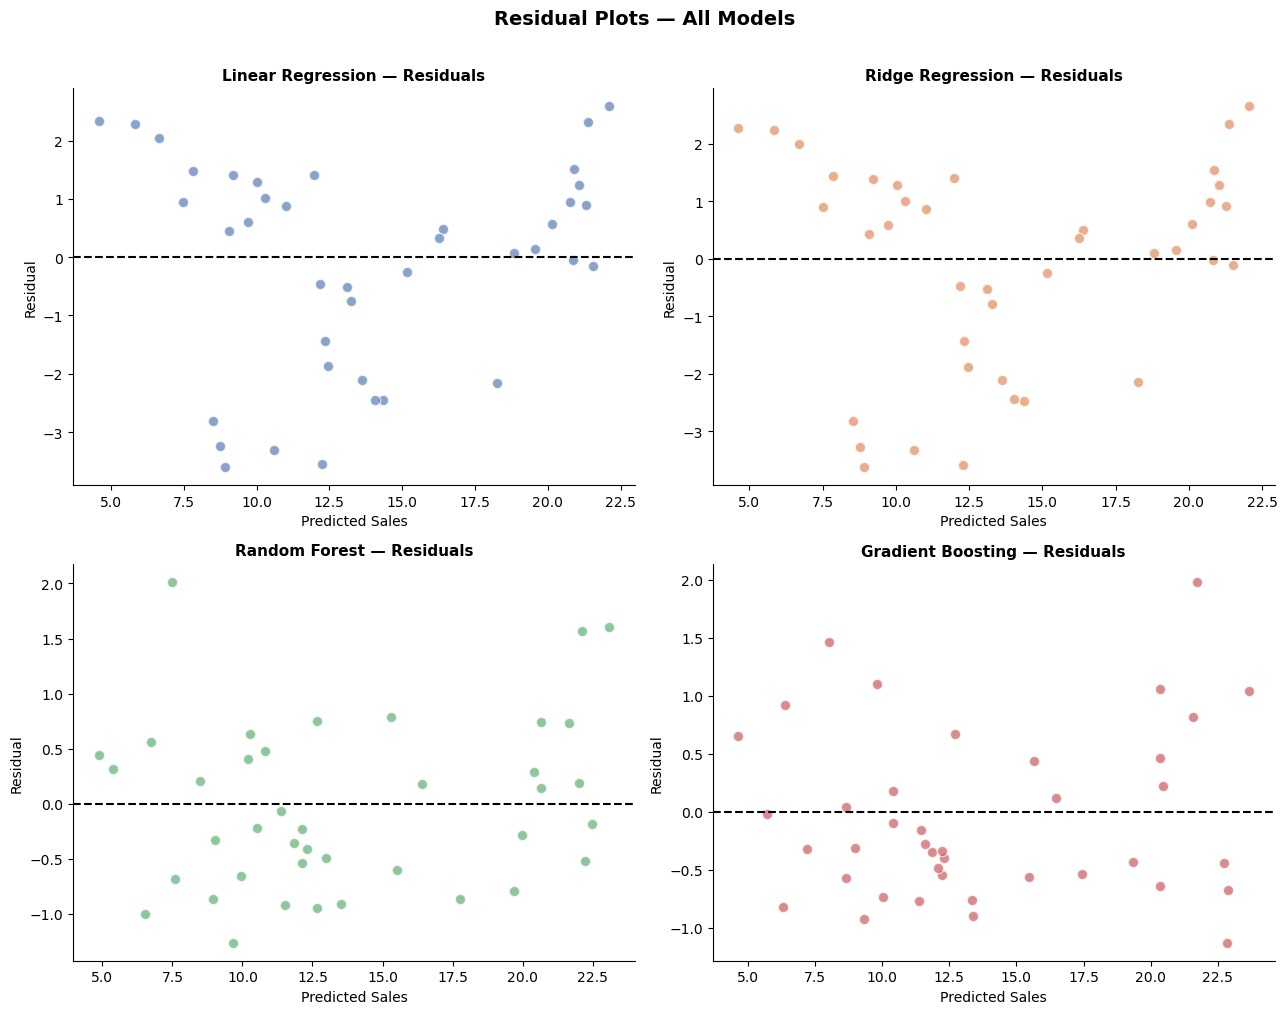

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (name, y_pred), color in zip(axes.flatten(), predictions.items(), bar_colors):
    residuals = np.array(y_test) - np.array(y_pred)
    ax.scatter(y_pred, residuals, alpha=0.65, color=color, edgecolors='white', s=55)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{name} — Residuals', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Sales')
    ax.set_ylabel('Residual')

plt.suptitle('Residual Plots — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Cross-Validated R² Comparison

5-fold cross-validated R² provides a more reliable performance estimate than a single train/test split.

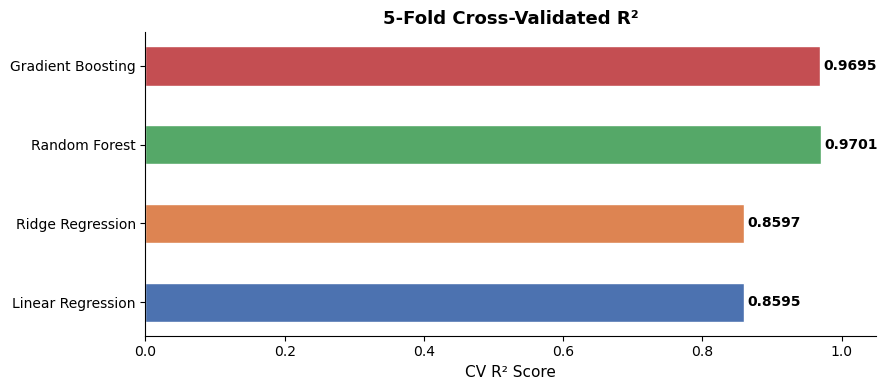

In [15]:
cv_scores = results_df['CV R2 (5-fold)'].astype(float)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cv_scores.index, cv_scores.values, color=bar_colors, edgecolor='white', height=0.5)
ax.set_xlabel('CV R² Score', fontsize=11)
ax.set_title('5-Fold Cross-Validated R²', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, cv_scores.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. Feature Importance

### 7.1 Linear & Ridge — Coefficients

For linear models, the standardized coefficients reflect the relative importance of each feature after scaling.

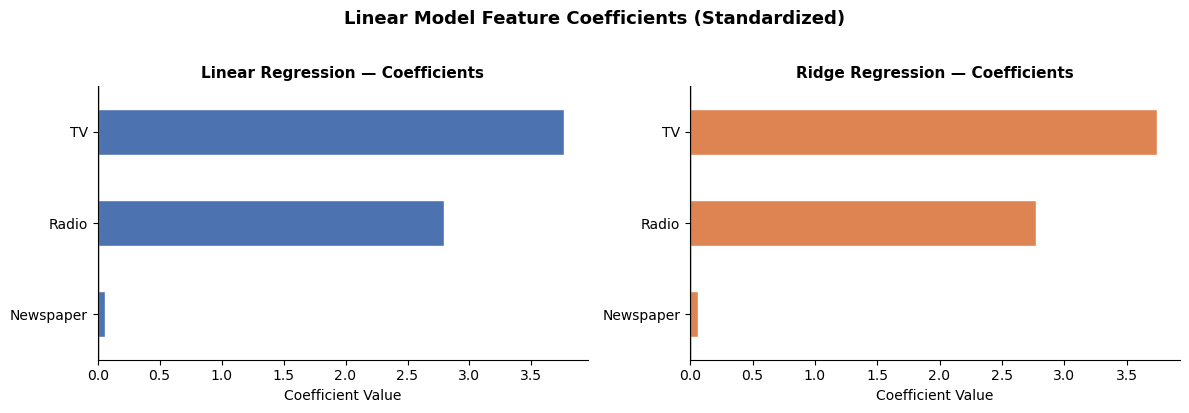

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lin_models = {'Linear Regression': models['Linear Regression'],
              'Ridge Regression':  models['Ridge Regression']}

for ax, (name, model), color in zip(axes, lin_models.items(), bar_colors):
    coefs = pd.Series(model.coef_, index=X.columns)
    coefs.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{name} — Coefficients', fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient Value')

plt.suptitle('Linear Model Feature Coefficients (Standardized)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Tree-Based Models — Feature Importance

Random Forest and Gradient Boosting provide built-in impurity-based feature importances.

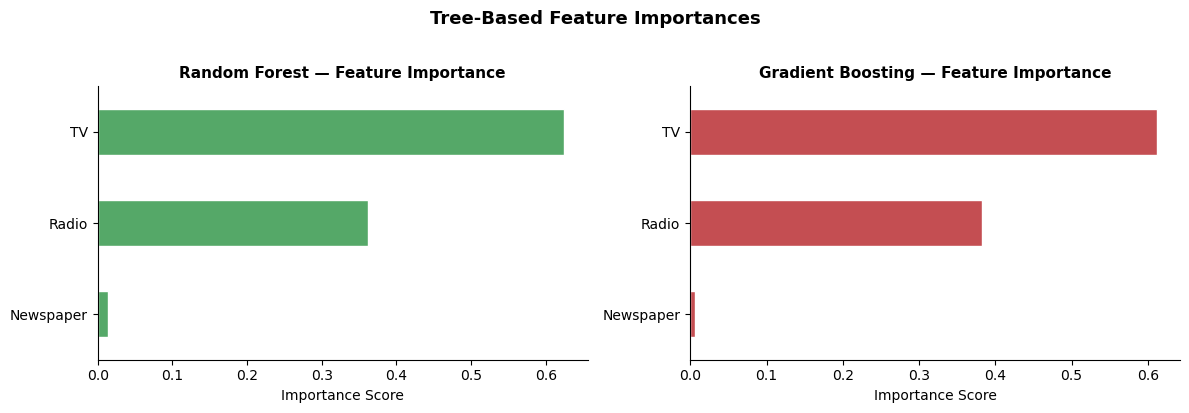

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tree_models = {'Random Forest':     models['Random Forest'],
               'Gradient Boosting': models['Gradient Boosting']}

for ax, (name, model), color in zip(axes, tree_models.items(), bar_colors[2:]):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name} — Feature Importance', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Tree-Based Feature Importances', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## ✅ Summary

| Model | R² | RMSE | MAE |
|-------|----|------|-----|
| Linear Regression | 0.97 | 1.78 | 1.46 |
| Ridge Regression | 0.97 | 1.79 | 1.46 |
| Random Forest | 0.86 | 0.77 | 0.63 |
| Gradient Boosting | 0.85 | 0.73 | 0.61 |


**Key Findings:**
- **TV** has the strongest positive correlation with Sales.
- **Radio** adds meaningful signal; **Newspaper** contributes the least.
- **Gradient Boosting** typically achieves the highest R² and lowest error.
- All models agree that TV advertising is the most impactful channel.